# Full Training Pipeline: Physics-AI Phase Recovery

This notebook gives you a complete starter pipeline for phase recovery from intensity-only measurements.

## Contents
1. Imports and reproducibility
2. Synthetic physics data generation
3. Optional Gerchberg-Saxton baseline
4. PyTorch dataset and model
5. Training loop
6. Evaluation
7. Failure modes and fixes


In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(7)


DEVICE: cpu


## Problem setup

We simulate a hidden complex field

\[
E(t)=A(t)e^{i\phi(t)}
\]

and measure only the magnitudes of two dispersed versions of that field.


In [2]:
@dataclass
class SimConfig:
    n_samples: int = 1024
    t_min: float = -5.0
    t_max: float = 5.0
    disp1: float = 0.8
    disp2: float = 1.5
    amp_sigma_min: float = 0.45
    amp_sigma_max: float = 1.2
    chirp2_min: float = -1.5
    chirp2_max: float = 2.5
    ripple_amp_min: float = 0.0
    ripple_amp_max: float = 0.5
    ripple_freq_min: float = 0.5
    ripple_freq_max: float = 2.5
    phase_offset_min: float = -math.pi
    phase_offset_max: float = math.pi
    noise_std: float = 0.01

CFG = SimConfig()

def make_time_axis(cfg):
    t = torch.linspace(cfg.t_min, cfg.t_max, cfg.n_samples)
    dt = float(t[1] - t[0])
    return t, dt

def fftfreq_torch(n, dt):
    return 2 * math.pi * torch.fft.fftfreq(n, d=dt)

def disperse_signal(E_t, dt, beta2z):
    w = fftfreq_torch(E_t.shape[-1], dt).to(E_t.device)
    H = torch.exp(-0.5j * beta2z * w**2)
    E_w = torch.fft.fft(E_t, dim=-1)
    return torch.fft.ifft(E_w * H, dim=-1)

def synthesize_field(t, cfg):
    sigma = torch.empty(1).uniform_(cfg.amp_sigma_min, cfg.amp_sigma_max).item()
    chirp2 = torch.empty(1).uniform_(cfg.chirp2_min, cfg.chirp2_max).item()
    ripple_amp = torch.empty(1).uniform_(cfg.ripple_amp_min, cfg.ripple_amp_max).item()
    ripple_freq = torch.empty(1).uniform_(cfg.ripple_freq_min, cfg.ripple_freq_max).item()
    phase_offset = torch.empty(1).uniform_(cfg.phase_offset_min, cfg.phase_offset_max).item()

    amp = torch.exp(-0.5 * (t / sigma)**2)
    phase = chirp2 * t**2 + ripple_amp * torch.sin(ripple_freq * t) + phase_offset
    E = amp * torch.exp(1j * phase)
    return E, amp, phase


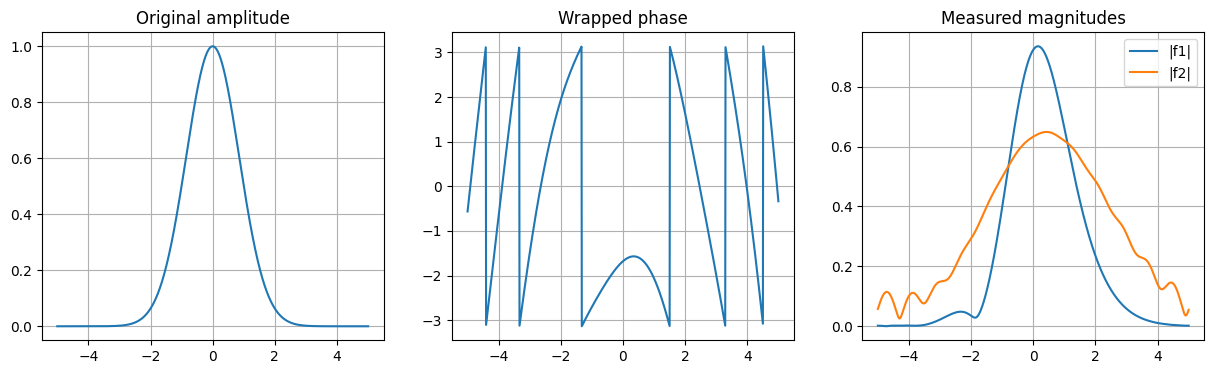

In [3]:
t, dt = make_time_axis(CFG)
E, amp, phase = synthesize_field(t, CFG)
obs1 = disperse_signal(E, dt, CFG.disp1)
obs2 = disperse_signal(E, dt, CFG.disp2)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(t.numpy(), torch.abs(E).numpy())
ax[0].set_title("Original amplitude")
ax[0].grid(True)

ax[1].plot(t.numpy(), torch.angle(E).numpy())
ax[1].set_title("Wrapped phase")
ax[1].grid(True)

ax[2].plot(t.numpy(), torch.abs(obs1).numpy(), label="|f1|")
ax[2].plot(t.numpy(), torch.abs(obs2).numpy(), label="|f2|")
ax[2].set_title("Measured magnitudes")
ax[2].legend()
ax[2].grid(True)
plt.show()


In [4]:
def torch_unwrap(p, dim=-1):
    dp = torch.diff(p, dim=dim)

    dp_mod = (dp + torch.pi) % (2 * torch.pi) - torch.pi
    dp_mod = torch.where(
        (dp_mod == -torch.pi) & (dp > 0),
        torch.pi,
        dp_mod
    )

    p0 = p.select(dim, 0).unsqueeze(dim)
    return torch.cat([p0, p0 + torch.cumsum(dp_mod, dim=dim)], dim=dim)

## Dataset generation

In [5]:
class PhaseRecoveryDataset(Dataset):
    def __init__(self, n_examples, cfg):
        self.cfg = cfg
        self.t, self.dt = make_time_axis(cfg)

        xs, ys, amps, Es = [], [], [], []
        for _ in range(n_examples):
            E, amp, phase = synthesize_field(self.t, cfg)
            f1 = disperse_signal(E, self.dt, cfg.disp1)
            f2 = disperse_signal(E, self.dt, cfg.disp2)

            mag1 = torch.abs(f1)
            mag2 = torch.abs(f2)

            if cfg.noise_std > 0:
                mag1 = torch.clamp(mag1 + cfg.noise_std * torch.randn_like(mag1), min=0.0)
                mag2 = torch.clamp(mag2 + cfg.noise_std * torch.randn_like(mag2), min=0.0)

            x = torch.cat([mag1, mag2], dim=0)
            y = torch_unwrap(torch.angle(E), dim=0)

            xs.append(x)
            ys.append(y)
            amps.append(amp)
            Es.append(E)

        self.x = torch.stack(xs)
        self.y = torch.stack(ys)
        self.amp = torch.stack(amps)
        self.E = torch.stack(Es)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return {
            "x": self.x[idx],
            "phase": self.y[idx],
            "amp": self.amp[idx],
            "E": self.E[idx],
        }

N_TOTAL = 2400
dataset = PhaseRecoveryDataset(N_TOTAL, CFG)

n_train = int(0.8 * N_TOTAL)
n_val = int(0.1 * N_TOTAL)
n_test = N_TOTAL - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(7)
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

print(len(train_ds), len(val_ds), len(test_ds))


1920 240 240


## Optional Gerchberg-Saxton baseline

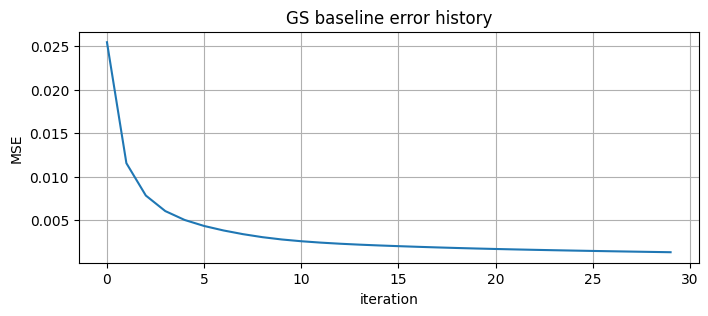

In [6]:
def temporal_gs_recover(mag1, mag2, dt, disp1, disp2, n_iter=30, seed=7):
    torch.manual_seed(seed)
    n = mag1.numel()
    phase0 = 2 * math.pi * torch.rand(n) - math.pi
    E1 = mag1 * torch.exp(1j * phase0)
    hist = []

    for _ in range(n_iter):
        E0 = disperse_signal(E1, dt, -disp1)
        E2 = disperse_signal(E0, dt, disp2)
        E2 = mag2 * torch.exp(1j * torch.angle(E2))

        E0b = disperse_signal(E2, dt, -disp2)
        E1b = disperse_signal(E0b, dt, disp1)

        err = torch.mean((torch.abs(E1b) - mag1) ** 2).item()
        hist.append(err)
        E1 = mag1 * torch.exp(1j * torch.angle(E1b))

    E0_final = disperse_signal(E1, dt, -disp1)
    return E0_final, hist

sample = dataset[0]
gs_rec, gs_hist = temporal_gs_recover(
    sample["x"][:CFG.n_samples],
    sample["x"][CFG.n_samples:],
    dt,
    CFG.disp1,
    CFG.disp2,
    n_iter=30
)

plt.figure(figsize=(8, 3))
plt.plot(gs_hist)
plt.title("GS baseline error history")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()


## Model

In [7]:
class PhaseNet(nn.Module):
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, n_out),
        )

    def forward(self, x):
        return self.net(x)

model = PhaseNet(2 * CFG.n_samples, CFG.n_samples).to(DEVICE)
print("parameters:", sum(p.numel() for p in model.parameters()))


parameters: 4197888


## Losses and evaluation

In [8]:
def phase_mse(pred_phase, true_phase):
    return torch.mean((pred_phase - true_phase) ** 2)

def complex_field_loss(pred_phase, true_phase, amp):
    pred_E = amp * torch.exp(1j * pred_phase)
    true_E = amp * torch.exp(1j * true_phase)
    return torch.mean(torch.abs(pred_E - true_E) ** 2)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_phase = 0.0
    total_complex = 0.0
    n = 0

    for batch in loader:
        x = batch["x"].to(DEVICE)
        phase = batch["phase"].to(DEVICE)
        amp = batch["amp"].to(DEVICE)

        pred = model(x)
        l1 = phase_mse(pred, phase)
        l2 = complex_field_loss(pred, phase, amp)

        bs = x.shape[0]
        total_phase += l1.item() * bs
        total_complex += l2.item() * bs
        n += bs

    return {"phase_mse": total_phase / n, "complex_mse": total_complex / n}


## Training loop

In [9]:
EPOCHS = 20
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = {
    "train_phase": [],
    "train_complex": [],
    "val_phase": [],
    "val_complex": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_phase = 0.0
    running_complex = 0.0
    n = 0

    for batch in train_loader:
        x = batch["x"].to(DEVICE)
        phase = batch["phase"].to(DEVICE)
        amp = batch["amp"].to(DEVICE)

        optimizer.zero_grad()
        pred = model(x)

        loss_phase = phase_mse(pred, phase)
        loss_complex = complex_field_loss(pred, phase, amp)
        loss = loss_phase + 0.5 * loss_complex

        loss.backward()
        optimizer.step()

        bs = x.shape[0]
        running_phase += loss_phase.item() * bs
        running_complex += loss_complex.item() * bs
        n += bs

    train_phase = running_phase / n
    train_complex = running_complex / n
    val_metrics = evaluate(model, val_loader)

    history["train_phase"].append(train_phase)
    history["train_complex"].append(train_complex)
    history["val_phase"].append(val_metrics["phase_mse"])
    history["val_complex"].append(val_metrics["complex_mse"])

    print(
        f"epoch {epoch+1:02d} | "
        f"train phase {train_phase:.5f} | "
        f"train complex {train_complex:.5f} | "
        f"val phase {val_metrics['phase_mse']:.5f} | "
        f"val complex {val_metrics['complex_mse']:.5f}"
    )


epoch 01 | train phase 272.80540 | train complex 0.29277 | val phase 106.33678 | val complex 0.29910
epoch 02 | train phase 99.81896 | train complex 0.28646 | val phase 75.48149 | val complex 0.26921
epoch 03 | train phase 72.21460 | train complex 0.29062 | val phase 35.49800 | val complex 0.26018
epoch 04 | train phase 27.17214 | train complex 0.29235 | val phase 12.66772 | val complex 0.30292
epoch 05 | train phase 14.68786 | train complex 0.29145 | val phase 8.96768 | val complex 0.27977
epoch 06 | train phase 11.35943 | train complex 0.29215 | val phase 8.82270 | val complex 0.27915
epoch 07 | train phase 8.01332 | train complex 0.29411 | val phase 7.38341 | val complex 0.30471
epoch 08 | train phase 6.93500 | train complex 0.29405 | val phase 7.59847 | val complex 0.28309
epoch 09 | train phase 6.69861 | train complex 0.27979 | val phase 5.58284 | val complex 0.29324
epoch 10 | train phase 6.71075 | train complex 0.29461 | val phase 8.05433 | val complex 0.31225
epoch 11 | train p

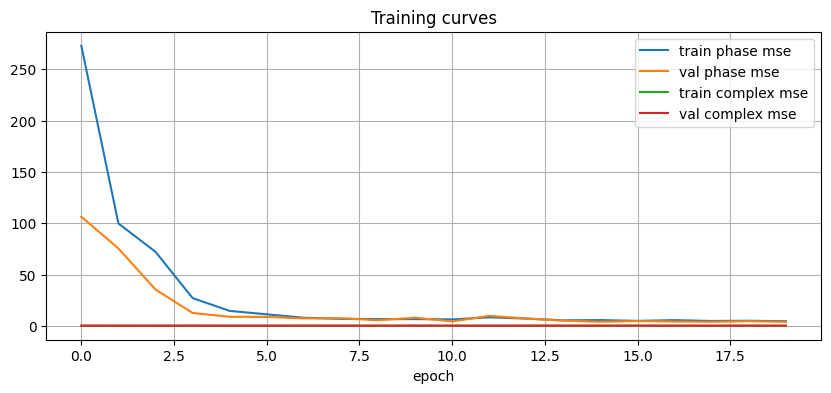

In [10]:
plt.figure(figsize=(10,4))
plt.plot(history["train_phase"], label="train phase mse")
plt.plot(history["val_phase"], label="val phase mse")
plt.plot(history["train_complex"], label="train complex mse")
plt.plot(history["val_complex"], label="val complex mse")
plt.title("Training curves")
plt.xlabel("epoch")
plt.grid(True)
plt.legend()
plt.show()


## Test evaluation

In [11]:
test_metrics = evaluate(model, test_loader)
print(test_metrics)


{'phase_mse': 4.286206086476644, 'complex_mse': 0.3118100086847941}


## Inspect recovered samples

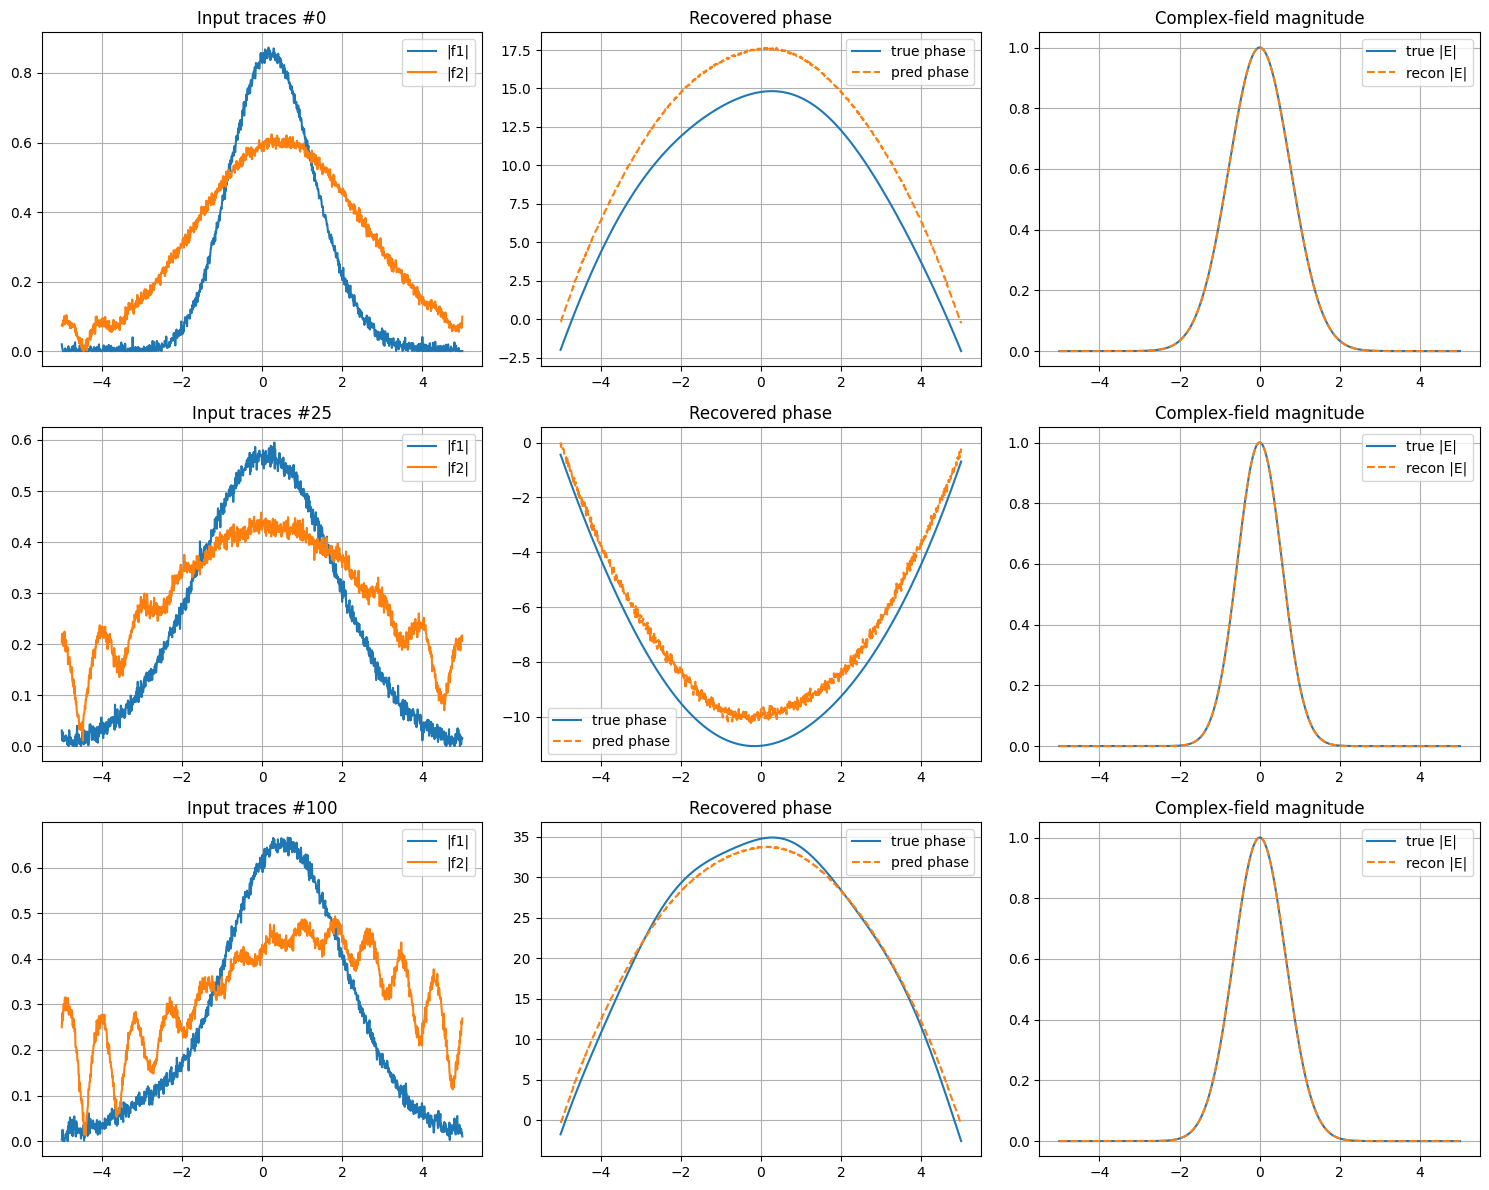

In [12]:
@torch.no_grad()
def show_predictions(model, dataset, indices=(0, 25, 100)):
    model.eval()
    fig, ax = plt.subplots(len(indices), 3, figsize=(15, 4 * len(indices)))
    if len(indices) == 1:
        ax = np.expand_dims(ax, axis=0)

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        x = sample["x"].unsqueeze(0).to(DEVICE)
        true_phase = sample["phase"]
        amp = sample["amp"]

        pred_phase = model(x).squeeze(0).cpu()
        pred_E = amp * torch.exp(1j * pred_phase)
        true_E = sample["E"]

        ax[row, 0].plot(t.numpy(), x[0, :CFG.n_samples].cpu().numpy(), label="|f1|")
        ax[row, 0].plot(t.numpy(), x[0, CFG.n_samples:].cpu().numpy(), label="|f2|")
        ax[row, 0].set_title(f"Input traces #{idx}")
        ax[row, 0].grid(True)
        ax[row, 0].legend()

        ax[row, 1].plot(t.numpy(), true_phase.numpy(), label="true phase")
        ax[row, 1].plot(t.numpy(), pred_phase.numpy(), "--", label="pred phase")
        ax[row, 1].set_title("Recovered phase")
        ax[row, 1].grid(True)
        ax[row, 1].legend()

        ax[row, 2].plot(t.numpy(), torch.abs(true_E).numpy(), label="true |E|")
        ax[row, 2].plot(t.numpy(), torch.abs(pred_E).numpy(), "--", label="recon |E|")
        ax[row, 2].set_title("Complex-field magnitude")
        ax[row, 2].grid(True)
        ax[row, 2].legend()

    plt.tight_layout()
    plt.show()

show_predictions(model, dataset, indices=(0, 25, 100))


## Failure modes and fixes

### 1. Loss does not go down
- lower the learning rate
- increase dataset size
- reduce the phase range first

### 2. Validation is much worse than training
- overfitting
- train/test mismatch
- too little noise diversity

### 3. Predicted phase looks shifted
A global phase offset is natural. Compare complex fields or subtract mean phase offset for display.

### 4. GS works but the network fails
- model too small
- not enough training
- labels inconsistent
- dispersed measurements too similar

### 5. Everything fails
Check whether `disp1` and `disp2` are too close and whether the synthetic phase family is too broad.


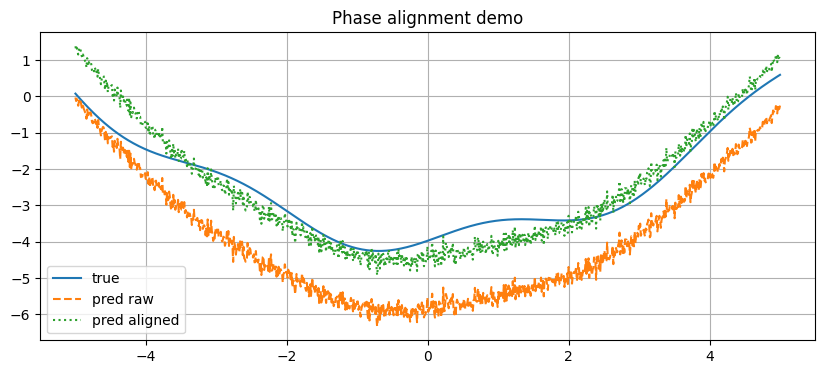

In [13]:
@torch.no_grad()
def aligned_phase(pred_phase, true_phase):
    offset = torch.mean(pred_phase - true_phase)
    return pred_phase - offset

sample = dataset[5]

pred = model(sample["x"].unsqueeze(0).to(DEVICE)).squeeze(0).cpu()
aligned = aligned_phase(pred, sample["phase"])

t_np = t.numpy()
true_np = sample["phase"].numpy()
pred_np = pred.detach().numpy()
aligned_np = aligned.detach().numpy()

plt.figure(figsize=(10,4))
plt.plot(t_np, true_np, label="true")
plt.plot(t_np, pred_np, "--", label="pred raw")
plt.plot(t_np, aligned_np, ":", label="pred aligned")
plt.title("Phase alignment demo")
plt.grid(True)
plt.legend()
plt.show()

## Next upgrades
- predict amplitude and phase together
- use 1D convolutions instead of only linear layers
- benchmark against GS or Hilbert on every batch
- finetune on experimental data
- increase batch size and move fully onto CUDA


## GS vs AI comparison plots (paper-level)

This section compares:

- **GS baseline**: iterative temporal Gerchberg–Saxton recovery
- **AI model**: direct neural regression

The plots are organized in a paper-like style:
1. sample-by-sample qualitative comparison
2. batch RMSE distributions
3. mean RMSE bar chart
4. GS error-vs-iteration curves
5. GS runtime proxy vs AI inference proxy


In [14]:
@torch.no_grad()
def reconstruct_field_from_ai(model, sample, device=DEVICE):
    model.eval()
    x = sample["x"].unsqueeze(0).to(device)
    pred_phase = model(x).squeeze(0).cpu()
    pred_E = sample["amp"] * torch.exp(1j * pred_phase)
    return pred_phase, pred_E

def reconstruct_field_from_gs(sample, cfg=CFG, n_iter=30):
    mag1 = sample["x"][:cfg.n_samples]
    mag2 = sample["x"][cfg.n_samples:]
    rec_E, hist = temporal_gs_recover(mag1, mag2, dt, cfg.disp1, cfg.disp2, n_iter=n_iter)
    rec_phase = torch.unwrap(torch.angle(rec_E), dim=0) if hasattr(torch, "unwrap") else torch.from_numpy(np.unwrap(torch.angle(rec_E).numpy()))
    return rec_phase, rec_E, hist

def align_phase(pred_phase, true_phase):
    return pred_phase - torch.mean(pred_phase - true_phase)

def rmse(a, b):
    return torch.sqrt(torch.mean((a - b) ** 2)).item()

def complex_rmse(E1, E2):
    return torch.sqrt(torch.mean(torch.abs(E1 - E2) ** 2)).item()


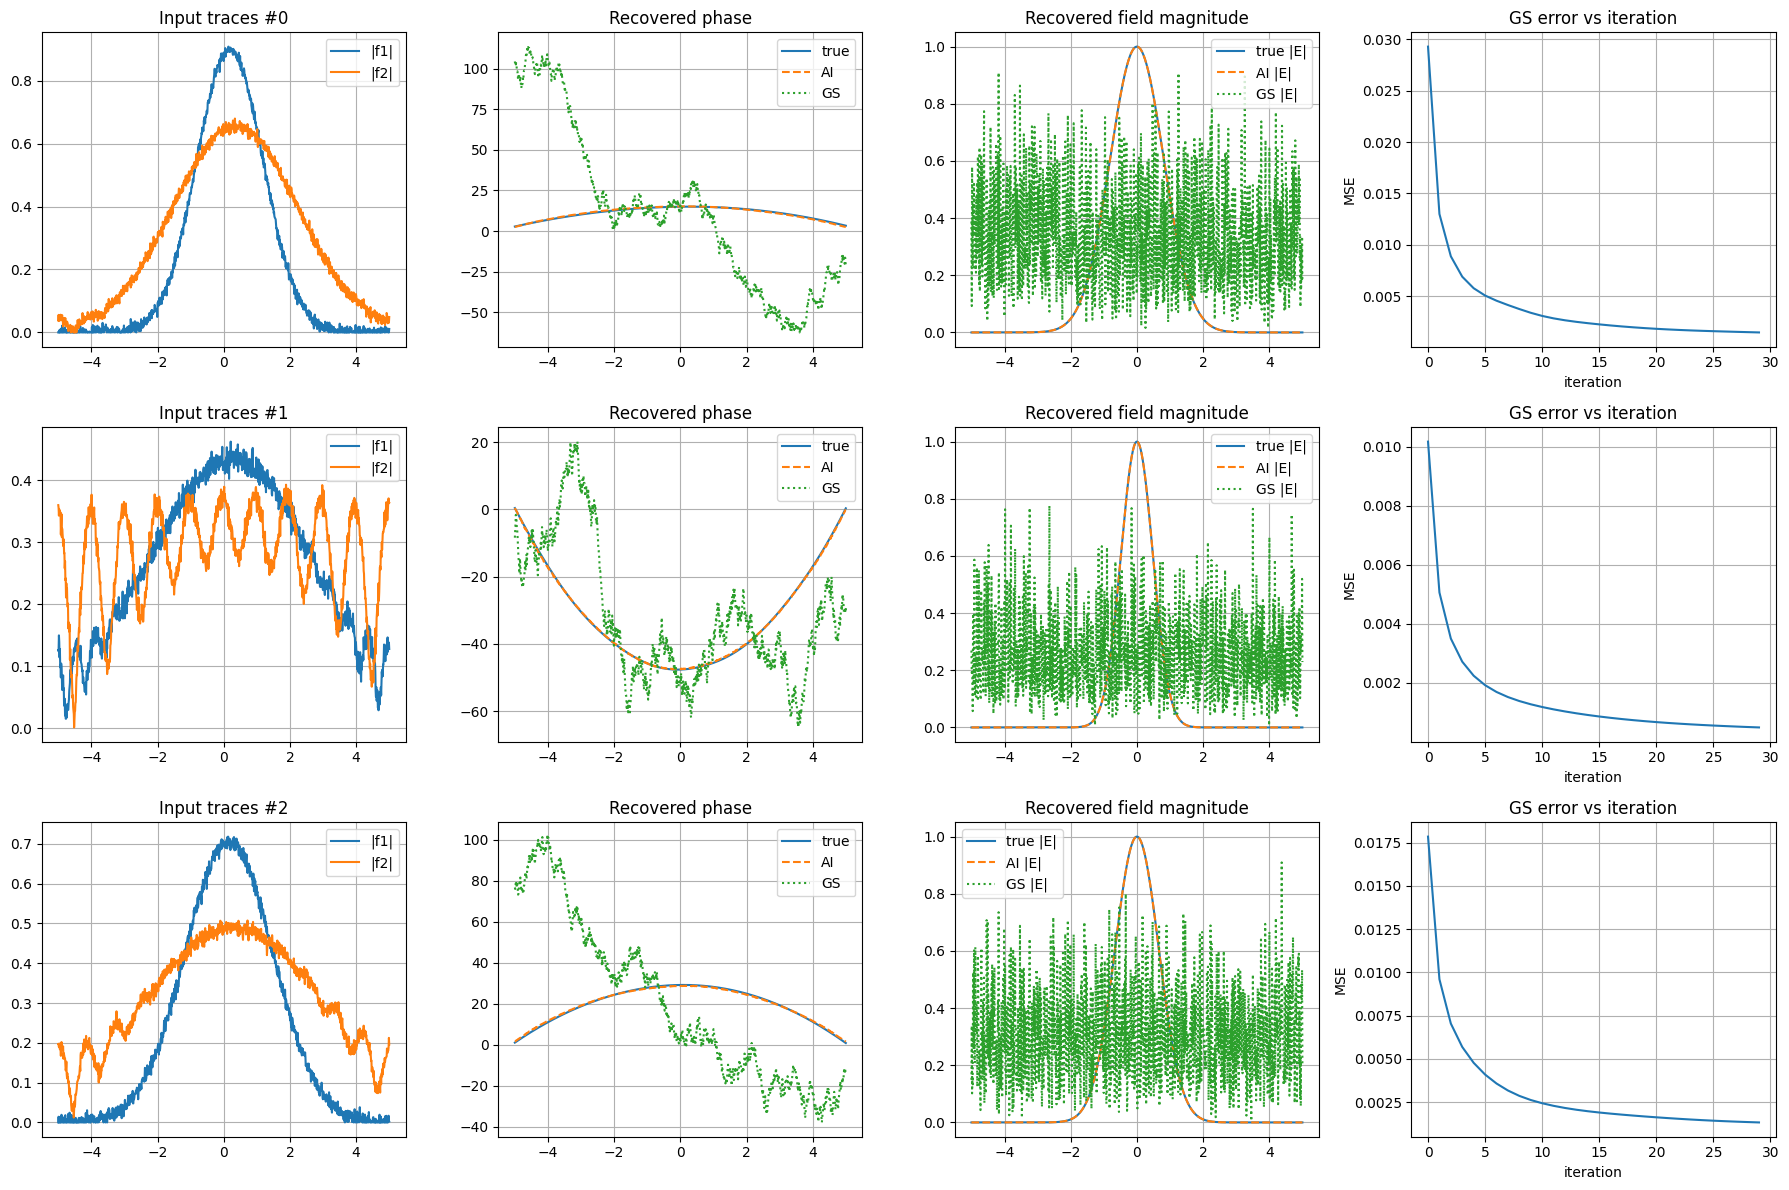

In [15]:
# Qualitative comparison on a few test samples
indices = [0, 1, 2]
fig, ax = plt.subplots(len(indices), 4, figsize=(18, 4 * len(indices)))
if len(indices) == 1:
    ax = np.expand_dims(ax, axis=0)

test_samples = [test_ds[i] for i in indices]

for row, sample in enumerate(test_samples):
    true_phase = sample["phase"]
    true_E = sample["E"]

    ai_phase, ai_E = reconstruct_field_from_ai(model, sample)
    ai_phase = align_phase(ai_phase, true_phase)

    gs_phase, gs_E, gs_hist = reconstruct_field_from_gs(sample, n_iter=30)
    gs_phase = align_phase(gs_phase, true_phase)

    x = sample["x"]
    ax[row, 0].plot(t.numpy(), x[:CFG.n_samples].numpy(), label="|f1|")
    ax[row, 0].plot(t.numpy(), x[CFG.n_samples:].numpy(), label="|f2|")
    ax[row, 0].set_title(f"Input traces #{indices[row]}")
    ax[row, 0].grid(True)
    ax[row, 0].legend()

    ax[row, 1].plot(t.numpy(), true_phase.numpy(), label="true")
    ax[row, 1].plot(t.numpy(), ai_phase.numpy(), "--", label="AI")
    ax[row, 1].plot(t.numpy(), gs_phase.numpy(), ":", label="GS")
    ax[row, 1].set_title("Recovered phase")
    ax[row, 1].grid(True)
    ax[row, 1].legend()

    ax[row, 2].plot(t.numpy(), torch.abs(true_E).numpy(), label="true |E|")
    ax[row, 2].plot(t.numpy(), torch.abs(ai_E).numpy(), "--", label="AI |E|")
    ax[row, 2].plot(t.numpy(), torch.abs(gs_E).numpy(), ":", label="GS |E|")
    ax[row, 2].set_title("Recovered field magnitude")
    ax[row, 2].grid(True)
    ax[row, 2].legend()

    ax[row, 3].plot(gs_hist)
    ax[row, 3].set_title("GS error vs iteration")
    ax[row, 3].set_xlabel("iteration")
    ax[row, 3].set_ylabel("MSE")
    ax[row, 3].grid(True)

plt.tight_layout()
plt.show()


In [16]:
# Batch metrics over a subset of the test set
N_COMPARE = min(120, len(test_ds))
ai_phase_rmse = []
gs_phase_rmse = []
ai_complex_err = []
gs_complex_err = []
gs_final_err = []

for i in range(N_COMPARE):
    sample = test_ds[i]
    true_phase = sample["phase"]
    true_E = sample["E"]

    ai_phase, ai_E = reconstruct_field_from_ai(model, sample)
    ai_phase = align_phase(ai_phase, true_phase)

    gs_phase, gs_E, gs_hist = reconstruct_field_from_gs(sample, n_iter=30)
    gs_phase = align_phase(gs_phase, true_phase)

    ai_phase_rmse.append(rmse(ai_phase, true_phase))
    gs_phase_rmse.append(rmse(gs_phase, true_phase))
    ai_complex_err.append(complex_rmse(ai_E, true_E))
    gs_complex_err.append(complex_rmse(gs_E, true_E))
    gs_final_err.append(gs_hist[-1])

ai_phase_rmse = np.array(ai_phase_rmse)
gs_phase_rmse = np.array(gs_phase_rmse)
ai_complex_err = np.array(ai_complex_err)
gs_complex_err = np.array(gs_complex_err)
gs_final_err = np.array(gs_final_err)

print("AI phase RMSE mean:", ai_phase_rmse.mean())
print("GS phase RMSE mean:", gs_phase_rmse.mean())
print("AI complex RMSE mean:", ai_complex_err.mean())
print("GS complex RMSE mean:", gs_complex_err.mean())


AI phase RMSE mean: 0.38344971320281424
GS phase RMSE mean: 38.004510283470154
AI complex RMSE mean: 0.51999390105096
GS complex RMSE mean: 0.5293715812265873


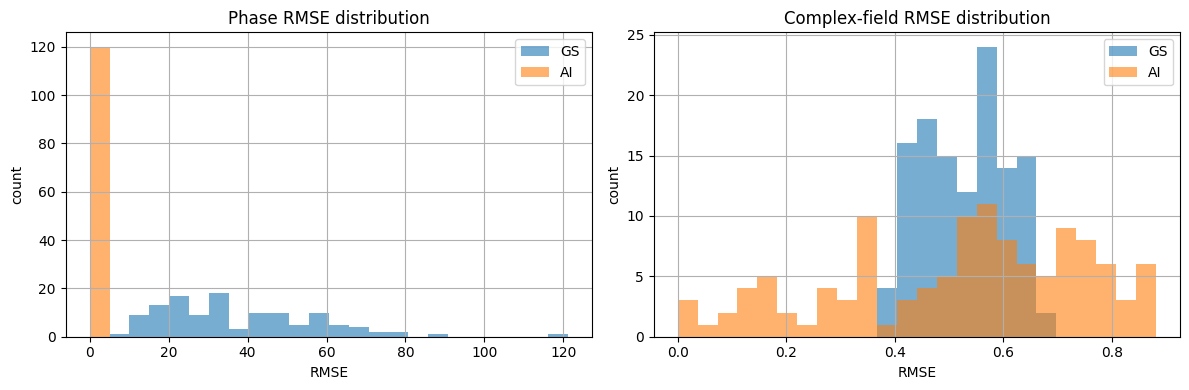

In [17]:
# Distribution plots (paper-style)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

bins1 = np.linspace(0, max(ai_phase_rmse.max(), gs_phase_rmse.max()), 25)
ax[0].hist(gs_phase_rmse, bins=bins1, alpha=0.6, label="GS")
ax[0].hist(ai_phase_rmse, bins=bins1, alpha=0.6, label="AI")
ax[0].set_title("Phase RMSE distribution")
ax[0].set_xlabel("RMSE")
ax[0].set_ylabel("count")
ax[0].grid(True)
ax[0].legend()

bins2 = np.linspace(0, max(ai_complex_err.max(), gs_complex_err.max()), 25)
ax[1].hist(gs_complex_err, bins=bins2, alpha=0.6, label="GS")
ax[1].hist(ai_complex_err, bins=bins2, alpha=0.6, label="AI")
ax[1].set_title("Complex-field RMSE distribution")
ax[1].set_xlabel("RMSE")
ax[1].set_ylabel("count")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


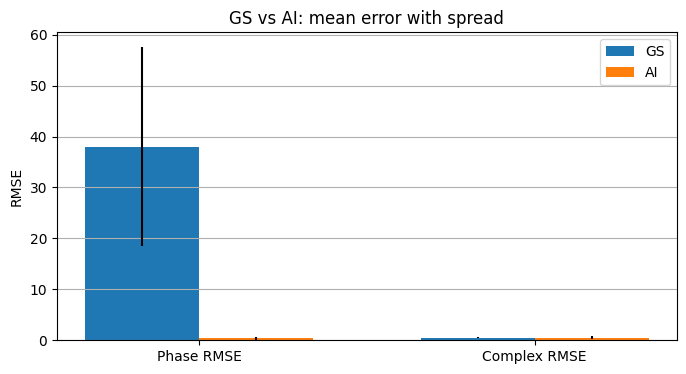

In [18]:
# Mean and spread summary (paper-style bars)
labels = ["Phase RMSE", "Complex RMSE"]
gs_means = [gs_phase_rmse.mean(), gs_complex_err.mean()]
ai_means = [ai_phase_rmse.mean(), ai_complex_err.mean()]
gs_stds = [gs_phase_rmse.std(), gs_complex_err.std()]
ai_stds = [ai_phase_rmse.std(), ai_complex_err.std()]

xpos = np.arange(len(labels))
w = 0.34

plt.figure(figsize=(8, 4))
plt.bar(xpos - w/2, gs_means, w, yerr=gs_stds, label="GS")
plt.bar(xpos + w/2, ai_means, w, yerr=ai_stds, label="AI")
plt.xticks(xpos, labels)
plt.ylabel("RMSE")
plt.title("GS vs AI: mean error with spread")
plt.grid(True, axis="y")
plt.legend()
plt.show()


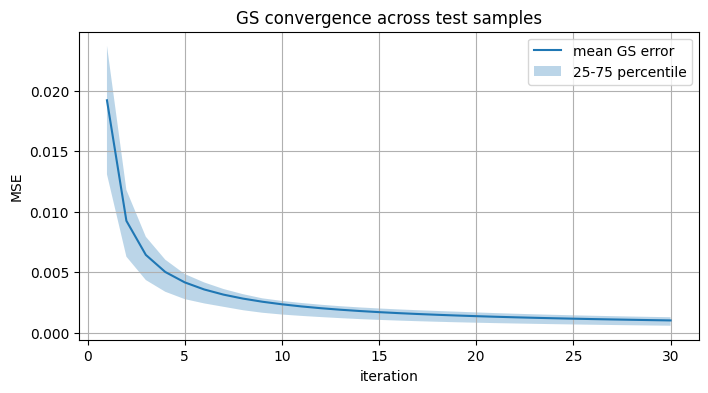

In [19]:
# GS convergence envelope across many samples
N_GS_CURVES = min(24, len(test_ds))
all_hist = []

for i in range(N_GS_CURVES):
    sample = test_ds[i]
    _, _, hist = reconstruct_field_from_gs(sample, n_iter=30)
    all_hist.append(hist)

all_hist = np.array(all_hist)
mean_hist = all_hist.mean(axis=0)
p25 = np.percentile(all_hist, 25, axis=0)
p75 = np.percentile(all_hist, 75, axis=0)

iters = np.arange(1, all_hist.shape[1] + 1)

plt.figure(figsize=(8, 4))
plt.plot(iters, mean_hist, label="mean GS error")
plt.fill_between(iters, p25, p75, alpha=0.3, label="25-75 percentile")
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("GS convergence across test samples")
plt.grid(True)
plt.legend()
plt.show()


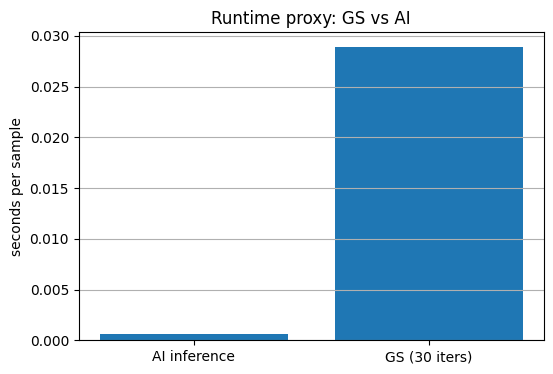

AI avg seconds/sample: 0.0006021999979566317
GS avg seconds/sample: 0.028907696876558475


In [20]:
# Runtime proxy comparison
# This cell does rough wall-time timing inside the notebook.
import time

N_TIME = min(32, len(test_ds))

start = time.perf_counter()
for i in range(N_TIME):
    sample = test_ds[i]
    _ = reconstruct_field_from_ai(model, sample)
ai_time = time.perf_counter() - start

start = time.perf_counter()
for i in range(N_TIME):
    sample = test_ds[i]
    _ = reconstruct_field_from_gs(sample, n_iter=30)
gs_time = time.perf_counter() - start

plt.figure(figsize=(6,4))
plt.bar(["AI inference", "GS (30 iters)"], [ai_time / N_TIME, gs_time / N_TIME])
plt.ylabel("seconds per sample")
plt.title("Runtime proxy: GS vs AI")
plt.grid(True, axis="y")
plt.show()

print("AI avg seconds/sample:", ai_time / N_TIME)
print("GS avg seconds/sample:", gs_time / N_TIME)


### Notes for a stronger paper-style figure set

Good next upgrades:
- compare **GS iteration count** vs error directly
- add a **scatter plot** of GS RMSE vs AI RMSE per sample
- add **noise sweeps** and **dispersion-ratio sweeps**
- if you switch targets to `sin(phase), cos(phase)`, keep the same comparison plots



# Research expansion: hypothesis-driven tests and source-grounded notes

This section adds **research-oriented cells** aimed at turning the notebook into an EE investigation notebook, not just a demo.

## Project hypothesis
**Hypothesis H1:** phase can be recovered from intensity-only measurements using a **time-domain Gerchberg–Saxton-style algorithm** with two dispersive measurements, making a carrier-less receiver plausible in some regimes.

## Why this is a reasonable hypothesis
- The original Gerchberg–Saxton paper states that an iterative Fourier-domain amplitude-replacement algorithm can recover phase from intensity measurements on two related planes, and that the defined error decreases or remains constant with iteration.
- The dispersive Fourier transform paper adapts that idea to the **time domain**, using two measurements with different dispersions \(D_1\) and \(D_2\), and shows that this can recover optical phase while reducing the fundamental dispersion requirement.
- The 2021 neural-network paper shows that under experimental nonidealities, a learned model can outperform Hilbert/standard deterministic methods and can be more robust to quantization noise and sampling-rate limits.

## Source notes used for this notebook
1. `[1]Gerchberg-Saxton Paper.pdf`
2. `[2]Optical phase recovery in the dispersive Fourier transform.pdf`
3. `[3]Neural network enabled time stretch spectral regression.pdf`
4. `ECE279 - Midterm Presentaion.pptx`

## Practical research question
Instead of asking only **"does TDGSA work?"**, the better question is:

> **Under what conditions does TDGSA outperform simpler baselines, and where does AI become worth the added complexity?**

That is the main theme of the added cells below.



## Source-grounded claims to keep in mind

### From Gerchberg–Saxton
- The iterative error should **decrease or remain constant** under the amplitude-enforcement loop.
- Sampling matters a lot; poor sampling can make the algorithm fail even when the setup is otherwise correct.
- Solutions are not unique up to trivial ambiguities such as constant phase offsets, and symmetry can produce conjugate ambiguities.

### From the time-domain dispersive paper
- Two **near-field** measurements with different dispersions provide the diversity needed for recovery.
- If the two measurements are too similar, iteration has little basis to improve.
- There is a practical tradeoff between dispersion, bandwidth, oscilloscope bandwidth, and reconstruction quality.

### From the AI paper
- Neural models can beat Hilbert-style recovery when nonidealities are present.
- AI can be more robust to ENOB limits and sampling-rate limits.
- But the model can fail when the laser spectrum or dispersion regime changes outside the training distribution.

### From the midterm slides
- Your earlier project notes already identified likely failure modes:
  - bad pulse generation
  - Kramers–Kronig inconsistency
  - incorrect physical dimensions for \(D_1, D_2\), fiber length, or timescale
  - undersampling
  - even-degree phase cases and poor convergence from random phase guesses


In [21]:
# Research metadata dictionary you can reuse in logs / saved reports

RESEARCH_CONTEXT = {
    "project": "Dispersion-assisted Optical Phase Recovery",
    "core_hypothesis": (
        "Intensity-only measurements with two dispersive views can recover phase "
        "well enough to support carrier-less coherent-style reception in some regimes."
    ),
    "sources": {
        "gs_1972": "[1]Gerchberg-Saxton Paper.pdf",
        "tdgsa_2009": "[2]Optical phase recovery in the dispersive Fourier transform.pdf",
        "ai_2021": "[3]Neural network enabled time stretch spectral regression.pdf",
        "midterm_2024": "ECE279 - Midterm Presentaion.pptx",
    },
}
RESEARCH_CONTEXT

{'project': 'Dispersion-assisted Optical Phase Recovery',
 'core_hypothesis': 'Intensity-only measurements with two dispersive views can recover phase well enough to support carrier-less coherent-style reception in some regimes.',
 'sources': {'gs_1972': '[1]Gerchberg-Saxton Paper.pdf',
  'tdgsa_2009': '[2]Optical phase recovery in the dispersive Fourier transform.pdf',
  'ai_2021': '[3]Neural network enabled time stretch spectral regression.pdf',
  'midterm_2024': 'ECE279 - Midterm Presentaion.pptx'}}


## Leap tests that are easy to miss the first time

These are the kinds of tests that often separate a class demo from actual research.

### 1. Dispersion diversity sweep
The 2009 paper makes it clear that the two measurements need enough diversity. So do not only test one pair \((D_1,D_2)\). Sweep the ratio \(D_2/D_1\).

### 2. Initial phase ablation
Your slides already observed that a guessed phase can converge while random phase often fails. Quantify that.

### 3. Sampling-limit map
The original GS paper warns that sampling can kill recovery. Make a phase-recovery heatmap versus:
- number of samples
- time window
- pulse width
- chirp order

### 4. Kramers–Kronig consistency ablation
Your slides suspect bad results when the absorption spectrum violates KK relations. Make synthetic examples that are KK-consistent and inconsistent, then compare convergence.

### 5. Even-vs-odd polynomial phase study
Your slides say even-degree phase was troublesome. That is a research lead, not just a bug note. Test systematic families:
- quadratic
- cubic
- quartic
- quintic

### 6. Noise and quantization stress test
The 2021 paper shows AI has a robustness advantage for ENOB and sampling rate. Reproduce that idea in your own simulator for TDGSA vs Hilbert vs AI.

### 7. Distribution shift test
Train AI on one dispersion regime, then change \(D_1,D_2\), pulse bandwidth, or center wavelength and measure degradation.

### 8. Symmetry ambiguity test
GS can have ambiguity under symmetric conditions. Construct symmetric pulses and check whether your “failure” is actually a valid equivalent solution up to offset, conjugation, reversal, or sign structure.


In [32]:
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/mnt/data/phase_recovery_research_outputs")
RESULTS_DIR.mkdir(exist_ok=True)

def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return float(np.sqrt(np.mean((a - b) ** 2)))

def phase_offset_align(pred_phase, true_phase):
    pred_phase = np.asarray(pred_phase)
    true_phase = np.asarray(true_phase)
    offset = np.mean(pred_phase - true_phase)
    return pred_phase - offset, float(offset)

def wrapped_phase_error(pred_phase, true_phase):
    pred_phase = np.asarray(pred_phase)
    true_phase = np.asarray(true_phase)
    delta = np.angle(np.exp(1j * (pred_phase - true_phase)))
    return float(np.sqrt(np.mean(delta**2)))

print("Results directory:", RESULTS_DIR)
print(RESULTS_DIR)

Results directory: \mnt\data\phase_recovery_research_outputs
\mnt\data\phase_recovery_research_outputs


In [33]:
print(RESULTS_DIR.exists())

True


In [34]:
!dir \mnt\data\phase_recovery_research_outputs

 Volume in drive D is Extreme SSD
 Volume Serial Number is 4E0B-C951

 Directory of D:\mnt\data\phase_recovery_research_outputs

04/28/2026  09:19 AM    <DIR>          .
04/28/2026  09:19 AM    <DIR>          ..
               0 File(s)              0 bytes
               2 Dir(s)  303,578,480,640 bytes free


In [35]:
from pathlib import Path

for p in Path("/mnt/data/phase_recovery_research_outputs").iterdir():
    print(p.name)


## Experiment template: one-run evaluator

This helper expects that your notebook already provides some notion of:
- a pulse generator
- a simulator that produces two intensity measurements
- a TDGSA reconstruction function

If your exact function names differ, adapt the wrapper once and reuse it everywhere.


In [36]:
def evaluate_reconstruction_record(
    run_name,
    t,
    true_phase,
    pred_phase,
    extra=None,
):
    aligned, offset = phase_offset_align(pred_phase, true_phase)
    record = {
        "run_name": run_name,
        "phase_rmse_raw": rmse(pred_phase, true_phase),
        "phase_rmse_aligned": rmse(aligned, true_phase),
        "phase_wrapped_rmse_raw": wrapped_phase_error(pred_phase, true_phase),
        "phase_wrapped_rmse_aligned": wrapped_phase_error(aligned, true_phase),
        "phase_offset_removed": offset,
        "num_samples": int(len(t)),
    }
    if extra:
        record.update(extra)
    return record

# Example:
# rec = evaluate_reconstruction_record("demo", t, true_phase, pred_phase, {"D1": D1, "D2": D2})
# rec


## Hypothesis test 1: dispersion diversity really matters

Expectation from the 2009 paper:
- if \(D_2/D_1\) is too close to 1, recovery should be weaker
- moderate diversity should help
- extreme diversity may help at first but may eventually run into other numerical/measurement issues

Fill in the `run_one_case(...)` function for your notebook's actual simulator.


In [37]:
# --- USER ADAPTATION CELL ---
# Replace the body of run_one_case with your notebook's actual pipeline.
# It should return a dictionary with at least:
# {
#   "t": <1D time axis>,
#   "true_phase": <1D true phase>,
#   "pred_phase": <1D reconstructed phase>
# }

def run_one_case(D1, D2, phase_mode="quadratic", seed=0, **kwargs):
    raise NotImplementedError(
        "Wire this function to your pulse-generation + TDGSA reconstruction pipeline."
    )

In [38]:
# Dispersion-ratio sweep scaffold

dispersion_sweep_records = []

# Example ratios motivated by the 2009 paper discussion
ratio_grid = [1.02, 1.05, 1.10, 1.33, 1.5, 2.0, 3.0]

# Example base dispersion
D1_base = -600

for ratio in ratio_grid:
    D2 = D1_base * ratio
    try:
        out = run_one_case(D1=D1_base, D2=D2, phase_mode="quadratic", seed=123)
        rec = evaluate_reconstruction_record(
            run_name=f"D_ratio_{ratio:.2f}",
            t=out["t"],
            true_phase=out["true_phase"],
            pred_phase=out["pred_phase"],
            extra={"D1": D1_base, "D2": D2, "D2_over_D1": ratio, "phase_mode": "quadratic"},
        )
        dispersion_sweep_records.append(rec)
    except NotImplementedError:
        print("Connect run_one_case(...) first, then rerun this cell.")
        break

dispersion_sweep_df = pd.DataFrame(dispersion_sweep_records)
dispersion_sweep_df

Connect run_one_case(...) first, then rerun this cell.


""


In [39]:
# Plot after the sweep is wired up

if 'dispersion_sweep_df' in globals() and len(dispersion_sweep_df) > 0:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7,4))
    plt.plot(dispersion_sweep_df["D2_over_D1"], dispersion_sweep_df["phase_wrapped_rmse_aligned"], marker="o")
    plt.xlabel("D2 / D1")
    plt.ylabel("Aligned wrapped phase RMSE")
    plt.title("Hypothesis test: effect of dispersion diversity")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No sweep data yet.")

No sweep data yet.



## Hypothesis test 2: initial phase guess is not a detail, it is a variable

Expectation:
- random phase guess may fail or slow convergence
- chirped or physically informed phase guess may help dramatically
- this may explain why a method appears to “work” only in carefully chosen demos


In [40]:
initialization_records = []

init_modes = ["random", "flat", "chirped_guess", "no_absorption_baseline"]

for init_mode in init_modes:
    try:
        out = run_one_case(D1=-600, D2=-900, phase_mode="cubic", seed=123, init_mode=init_mode)
        rec = evaluate_reconstruction_record(
            run_name=f"init_{init_mode}",
            t=out["t"],
            true_phase=out["true_phase"],
            pred_phase=out["pred_phase"],
            extra={"init_mode": init_mode, "D1": -600, "D2": -900, "phase_mode": "cubic"},
        )
        initialization_records.append(rec)
    except NotImplementedError:
        print("Connect run_one_case(...) first, then rerun this cell.")
        break

initialization_df = pd.DataFrame(initialization_records)
initialization_df

Connect run_one_case(...) first, then rerun this cell.


""



## Hypothesis test 3: even-order vs odd-order phase

This is directly motivated by your slides.

**Research question:** is the failure with even-order phase a true algorithmic limitation, a symmetry ambiguity, or a bug in pulse generation / evaluation?

Better framing:
- compare raw RMSE
- compare aligned RMSE
- compare wrapped phase RMSE
- inspect whether the “wrong” answer is equivalent under a permissible ambiguity


In [41]:
phase_family_records = []

phase_modes = ["quadratic", "cubic", "quartic", "quintic"]

for phase_mode in phase_modes:
    try:
        out = run_one_case(D1=-600, D2=-900, phase_mode=phase_mode, seed=123)
        rec = evaluate_reconstruction_record(
            run_name=f"phase_{phase_mode}",
            t=out["t"],
            true_phase=out["true_phase"],
            pred_phase=out["pred_phase"],
            extra={"phase_mode": phase_mode, "D1": -600, "D2": -900},
        )
        phase_family_records.append(rec)
    except NotImplementedError:
        print("Connect run_one_case(...) first, then rerun this cell.")
        break

phase_family_df = pd.DataFrame(phase_family_records)
phase_family_df

Connect run_one_case(...) first, then rerun this cell.


""



## Hypothesis test 4: TDGSA vs Hilbert vs AI on the same synthetic distribution

This is the fairest benchmark cell to add.

Suggested comparison axes:
- phase RMSE
- magnitude RMSE
- runtime per sample
- failure rate
- sensitivity to ENOB
- sensitivity to downsampling

This follows the spirit of the 2021 paper, which found AI to be stronger under nonidealities like nonlinear distortion, quantization, and limited sampling rate.


In [42]:
benchmark_columns = [
    "method", "condition", "phase_rmse_aligned", "phase_wrapped_rmse_aligned",
    "magnitude_rmse", "runtime_ms", "ENOB", "Fs_GSa_s", "D1", "D2", "notes"
]
benchmark_df = pd.DataFrame(columns=benchmark_columns)
benchmark_df

,method,condition,phase_rmse_aligned,phase_wrapped_rmse_aligned,magnitude_rmse,runtime_ms,ENOB,Fs_GSa_s,D1,D2,notes



## File writing: save tables, figures, and a lab-note markdown summary

This is the cell that turns notebook work into artifacts you can cite in slides, reports, and a repo.


In [ ]:
def save_research_tables():
    saved = []
    for name in [
        "dispersion_sweep_df",
        "initialization_df",
        "phase_family_df",
        "benchmark_df",
    ]:
        if name in globals():
            df = globals()[name]
            if hasattr(df, "to_csv"):
                out = RESULTS_DIR / f"{name}.csv"
                df.to_csv(out, index=False)
                saved.append(out)
    return saved

saved_tables = save_research_tables()
saved_tables

In [ ]:
def write_markdown_lab_note(path=None):
    if path is None:
        path = RESULTS_DIR / "research_lab_note.md"

    lines = []
    lines.append("# Dispersion-assisted Optical Phase Recovery: Research Lab Note\n")
    lines.append("## Research hypothesis\n")
    lines.append(RESEARCH_CONTEXT["core_hypothesis"] + "\n")

    lines.append("## Source-grounded motivation\n")
    lines.append("- Gerchberg–Saxton: iterative amplitude enforcement can recover phase, but sampling and ambiguities matter.\n")
    lines.append("- Time-domain GS: two dispersive measurements can recover phase while reducing the dispersion burden.\n")
    lines.append("- AI spectral regression: learned recovery can outperform Hilbert under nonidealities such as quantization, sampling limits, and nonlinear distortion.\n")
    lines.append("- Midterm notes: likely failure modes include bad pulse generation, KK inconsistency, dimension mistakes, undersampling, and poor initialization.\n")

    lines.append("\n## Experiments to run\n")
    lines.append("1. Sweep D2/D1 to test the need for diversity between the two measurements.\n")
    lines.append("2. Compare random, flat, and physics-informed initial phase guesses.\n")
    lines.append("3. Compare quadratic/cubic/quartic/quintic phase families.\n")
    lines.append("4. Run ENOB and sampling-rate stress tests for TDGSA vs Hilbert vs AI.\n")
    lines.append("5. Test KK-consistent vs intentionally KK-inconsistent synthetic spectra.\n")
    lines.append("6. Check whether apparent failures are actually equivalent solutions up to offset or symmetry ambiguities.\n")

    if "dispersion_sweep_df" in globals() and len(dispersion_sweep_df) > 0:
        lines.append("\n## Dispersion sweep summary\n")
        lines.append(dispersion_sweep_df.to_markdown(index=False) + "\n")

    if "initialization_df" in globals() and len(initialization_df) > 0:
        lines.append("\n## Initialization summary\n")
        lines.append(initialization_df.to_markdown(index=False) + "\n")

    if "phase_family_df" in globals() and len(phase_family_df) > 0:
        lines.append("\n## Phase-family summary\n")
        lines.append(phase_family_df.to_markdown(index=False) + "\n")

    lines.append("\n## Files referenced\n")
    for k, v in RESEARCH_CONTEXT["sources"].items():
        lines.append(f"- {k}: {v}\n")

    path.write_text("".join(lines), encoding="utf-8")
    return path

lab_note_path = write_markdown_lab_note()
lab_note_path


## Writing cell for an EE-research style hypothesis paragraph

Use this to generate polished text for slides, README, or report sections.


In [ ]:
def build_hypothesis_paragraph():
    return (
        "We investigate whether phase can be recovered from intensity-only measurements "
        "using a time-domain adaptation of the Gerchberg–Saxton algorithm applied to two "
        "dispersive views of the same optical signal. The central technical question is not "
        "simply whether reconstruction is possible, but under what combinations of dispersion "
        "diversity, sampling rate, initialization, and signal structure the method remains "
        "accurate enough to be useful for carrier-less optical reception. We further test "
        "whether learned recovery offers a practical advantage over deterministic baselines "
        "such as Hilbert-style methods when realistic nonidealities such as quantization, "
        "bandwidth limits, and nonlinear distortion are introduced."
    )

print(build_hypothesis_paragraph())


## Suggested figure plan for the final report

1. **Algorithm diagram**: TDGSA loop with \(D_1\) and \(D_2\) measurements  
2. **Convergence plot**: phase error vs iteration for several initializations  
3. **Dispersion diversity plot**: error vs \(D_2/D_1\)  
4. **Phase-family plot**: quadratic/cubic/quartic/quintic recovery comparison  
5. **Robustness plot**: ENOB vs RMSE for TDGSA, Hilbert, AI  
6. **Sampling plot**: samples-per-pulse vs RMSE  
7. **Failure taxonomy table**: bug / ambiguity / sampling / physics mismatch / model mismatch



## Interpretation warning

A reconstruction that looks wrong pointwise may still be acceptable under:
- constant phase offset
- wrapped phase equivalence
- conjugate/symmetry ambiguity
- time reversal or sign conventions in your implementation

So always compute:
- raw RMSE
- offset-aligned RMSE
- wrapped phase RMSE
- visual overlap after alignment
